In [1]:
%load_ext autoreload
%autoreload 2

In [1]:
import io
import os, sys
import requests
import PIL

import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF

from dall_e import map_pixels, unmap_pixels, load_model
from dall_e import Encoder
from dall_e import Decoder
from IPython.display import display, display_markdown


In [8]:
target_image_size = 512

def download_image(url):
    resp = requests.get(url)
    resp.raise_for_status()
    return PIL.Image.open(io.BytesIO(resp.content))

def preprocess(img):
    # s = min(img.size)
    
    # if s < target_image_size:
    #     raise ValueError(f'min dim for image {s} < {target_image_size}')
        
    # r = img.size[0] / img.size[1]
    # s = (round(r * img.size[1]), round(r * img.size[0]))
    # img = TF.resize(img, s, interpolation=PIL.Image.LANCZOS)
    # img = TF.center_crop(img, output_size=2 * [target_image_size])
    img = torch.unsqueeze(T.ToTensor()(img), 0)
    return map_pixels(img)

In [3]:
# This can be changed to a GPU, e.g. 'cuda:0'.
dev = torch.device('cuda:0')

# For faster load times, download these files locally and use the local paths instead.
enc: Encoder = load_model("https://cdn.openai.com/dall-e/encoder.pkl", dev)
dec: Decoder = load_model("https://cdn.openai.com/dall-e/decoder.pkl", dev)

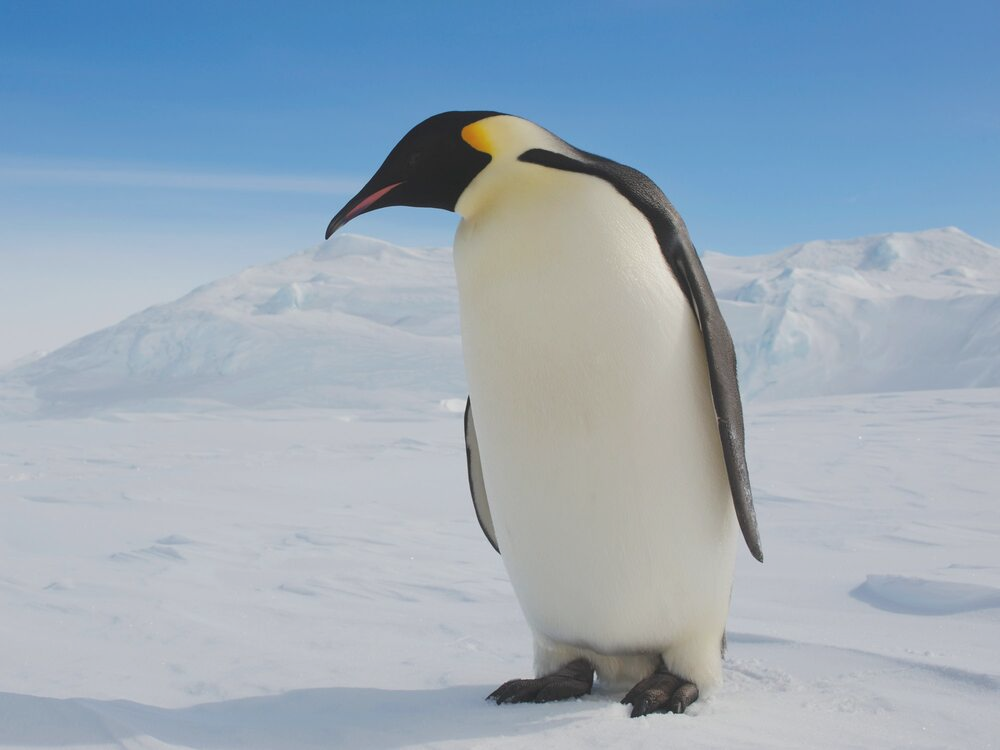

In [9]:
x = preprocess(download_image('https://assets.bwbx.io/images/users/iqjWHBFdfxIU/iKIWgaiJUtss/v2/1000x-1.jpg'))
display_markdown('Original image:')
display(T.ToPILImage(mode='RGB')(x[0]))

torch.Size([1, 64, 64])
torch.Size([1, 8192, 64, 64])


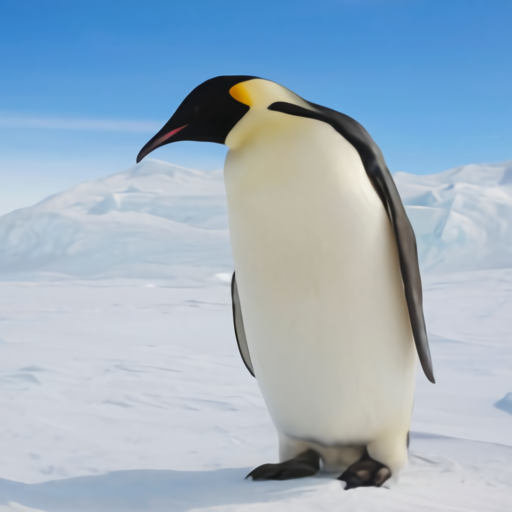

In [5]:

import torch.nn.functional as F

z_logits = enc(x.to(dev))
z = torch.argmax(z_logits, axis=1)
print(z.shape)
z = F.one_hot(z, num_classes=enc.vocab_size).permute(0, 3, 1, 2).float()
print(z.shape)

x_stats = dec(z).float()
x_rec = unmap_pixels(torch.sigmoid(x_stats[:, :3]))
x_rec = T.ToPILImage(mode='RGB')(x_rec[0])

display_markdown('Reconstructed image:')
display(x_rec)